In [2]:
SUBJECT_IDS = list(range(1, 11)) # first ten
# SUBJECT_IDS = list(range(1, 110)) # full

# # executed
# RUNS_FOR_TRAINING = [3, 7]
# RUNS_FOR_TESTING = [11]
# motor imagery
RUNS_FOR_TRAINING = [4, 8]
RUNS_FOR_TESTING = [12]

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
import mne
from mne.decoding import CSP

In [4]:
# 1. Data Loading and Preprocessing Function
def load_and_epoch(subject_id: int, runs: list, tmin=0.5, tmax=3.5, l_freq=8.0, h_freq=30.0):
    """
    Loads specified runs for a subject, applies bandpass filter, and extracts 3-second epochs.
    """
    file_paths = mne.datasets.eegbci.load_data(subjects=subject_id, runs=runs, update_path=False)
    
    # Load each EDF and standardize channel names on ALL of them
    raws = []
    for f in file_paths:
        r = mne.io.read_raw_edf(f, preload=True)
        mne.datasets.eegbci.standardize(r)  # Strips trailing dots and cleans names
        raws.append(r)
    
    montage = mne.channels.make_standard_montage('standard_1005')
    
    raw = mne.concatenate_raws(raws)
    raw.set_montage(montage, match_case=False)
    
    # Universal preprocessing: 8-30 Hz Sensorimotor Band
    raw.filter(l_freq, h_freq, fir_design='firwin', skip_by_annotation='edge')
    
    # Extract events: T1 (Left Fist), T2 (Right Fist)
    events, event_dict = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2})
    
    # Epoching: 0.5s to 3.5s after the visual cue
    epochs = mne.Epochs(
        raw, 
        events, 
        event_id=event_dict, 
        tmin=tmin, 
        tmax=tmax, 
        baseline=None, 
        preload=True
    )
    
    X = epochs.get_data(copy=False)  # Shape: (trials, channels, timepoints)
    y = epochs.events[:, -1] - 1     # Map T1->0 (Left), T2->1 (Right)
    
    return epochs, X, y

In [5]:
# silence the mne logs if you want to avoid huge logs from next cell
mne.set_log_level('WARNING')

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP

records = []
fitted_pipelines = {}
cached_train_infos = {}

print("=== Starting Intra-Subject Batch Benchmark ===")
for sub in SUBJECT_IDS:
    try:
        # 1. Load data
        train_epochs, X_train, y_train = load_and_epoch(sub, RUNS_FOR_TRAINING)
        test_epochs, X_test, y_test = load_and_epoch(sub, RUNS_FOR_TESTING)
        
        # 2. Fit pipeline strictly on Runs 3 & 7
        csp = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
        lda = LinearDiscriminantAnalysis()
        clf = Pipeline([("CSP", csp), ("LDA", lda)])
        
        clf.fit(X_train, y_train)
        
        # 3. Evaluate strictly on Run 11
        acc = clf.score(X_test, y_test)
        
        # Store for analysis and plotting
        records.append({
            "Subject": f"S{sub:02d}",
            "Subject_ID": sub,
            "Accuracy": acc,
            "Train_Trials": len(y_train),
            "Test_Trials": len(y_test)
        })
        fitted_pipelines[sub] = clf
        cached_train_infos[sub] = train_epochs.info
        
        print(f"Subject {sub:02d} | Accuracy: {acc:6.2%} (Test trials: {len(y_test)})")
        
    except Exception as e:
        print(f"Subject {sub:02d} failed: {e}")

df_intra = pd.DataFrame(records)

# 4. Statistical Inference against 50% chance baseline
accuracies = df_intra['Accuracy'].values
n = len(accuracies)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies, ddof=1)
sem_acc = std_acc / np.sqrt(n)

t_stat, p_val_two_sided = stats.ttest_1samp(accuracies, popmean=0.50)
p_val_one_sided = p_val_two_sided / 2 if t_stat > 0 else 1.0 - (p_val_two_sided / 2)
ci_lower, ci_upper = stats.t.interval(0.95, df=n - 1, loc=mean_acc, scale=sem_acc)

print("\n" + "=" * 48)
print(f"Cohort Size: {n} subjects evaluated")
print(f"Intra-Subject Mean Accuracy: {mean_acc:.2%} ± {std_acc:.2%} (SD)")
print(f"Standard Error (SEM): ± {sem_acc:.2%}")
print(f"95% Confidence Interval: [{ci_lower:.2%}, {ci_upper:.2%}]")
print(f"One-Sample t-test (vs 50%): t({n-1}) = {t_stat:.3f}")
print(f"  p-value (one-tailed, μ > 0.50): {p_val_one_sided:.4e}")
print(f"  p-value (two-tailed, μ ≠ 0.50): {p_val_two_sided:.4e}")
print(f"Min / Max: {df_intra['Accuracy'].min():.2%} / {df_intra['Accuracy'].max():.2%}")
print("=" * 48)

=== Starting Intra-Subject Batch Benchmark ===


c:\Users\jason\Projects\ntab-eeg-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')
C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')


Subject 01 | Accuracy: 66.67% (Test trials: 15)


C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')
C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')


Subject 02 | Accuracy: 73.33% (Test trials: 15)


...

Subject 08 | Accuracy: 46.67% (Test trials: 15)


C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')
C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')


Subject 09 | Accuracy: 53.33% (Test trials: 15)


C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')
C:\Users\jason\AppData\Local\Temp\ipykernel_14596\3664225072.py:15: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = mne.channels.make_standard_montage('standard_1005')


Subject 10 | Accuracy: 53.33% (Test trials: 15)

Cohort Size: 10 subjects evaluated
Intra-Subject Mean Accuracy: 59.33% ± 17.34% (SD)
Standard Error (SEM): ± 5.48%
95% Confidence Interval: [46.93%, 71.74%]
One-Sample t-test (vs 50%): t(9) = 1.702
  p-value (one-tailed, μ > 0.50): 6.1488e-02
  p-value (two-tailed, μ ≠ 0.50): 1.2298e-01
Min / Max: 40.00% / 100.00%


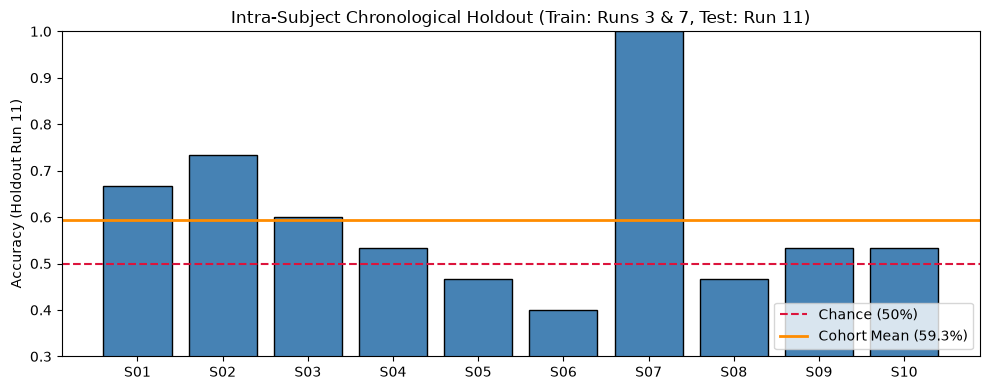

Generating Topomap Comparison: Best (S07) vs Worst (S06)...


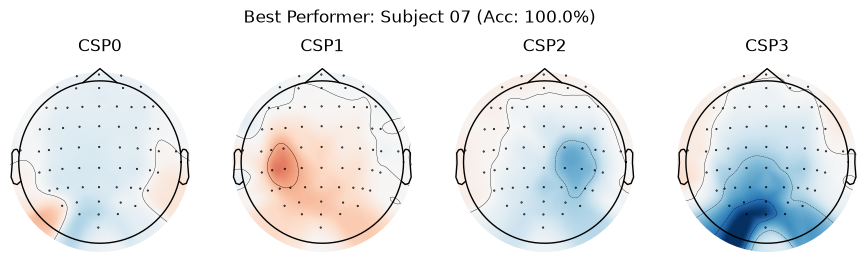

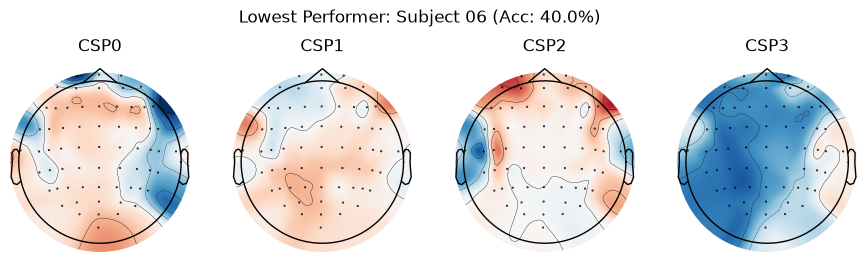

In [8]:
import matplotlib.pyplot as plt

# 1. Plot Cohort Accuracy Bar Chart
plt.figure(figsize=(10, 4))
bars = plt.bar(df_intra["Subject"], df_intra["Accuracy"], color="steelblue", edgecolor="black")
plt.axhline(0.50, color="crimson", linestyle="--", linewidth=1.5, label="Chance (50%)")
mean_val = df_intra["Accuracy"].mean()
plt.axhline(mean_val, color="darkorange", linestyle="-", linewidth=2, label=f"Cohort Mean ({mean_val:.1%})")

plt.ylim(0.3, 1.0)
plt.ylabel("Accuracy (Holdout Run 11)")
plt.title("Intra-Subject Chronological Holdout (Train: Runs 3 & 7, Test: Run 11)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 2. Topomap Comparison: Best vs. Worst Subject
best_sub = df_intra.loc[df_intra["Accuracy"].idxmax()]["Subject_ID"]
worst_sub = df_intra.loc[df_intra["Accuracy"].idxmin()]["Subject_ID"]

print(f"Generating Topomap Comparison: Best (S{best_sub:02d}) vs Worst (S{worst_sub:02d})...")

for sub_id, role in [(best_sub, "Best Performer"), (worst_sub, "Lowest Performer")]:
    clf_to_plot = fitted_pipelines[sub_id]
    info_to_plot = cached_train_infos[sub_id]
    csp_step = clf_to_plot.named_steps["CSP"]
    
    fig, axes = plt.subplots(1, 4, figsize=(11, 2.5))
    csp_step.plot_patterns(info_to_plot, components=np.arange(4), axes=axes, colorbar=False, show=False)
    fig.suptitle(f"{role}: Subject {sub_id:02d} (Acc: {df_intra.loc[df_intra['Subject_ID']==sub_id, 'Accuracy'].values[0]:.1%})", y=1.08)
    plt.show()